# Indian Weather & Rainfall Analysis

# 03 - Exploratory Data Analysis (EDA)

---

## Objective

The objective of this notebook is to explore the cleaned weather dataset and uncover meaningful insights through data visualization and statistical analysis.

### The analysis focuses on:

- Understanding temperature distribution
- Analyzing rainfall patterns
- Comparing weather across Indian states
- Studying seasonal weather changes
- Identifying yearly trends
- Exploring relationships among weather variables

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/cleaned_weather_data.csv")
df["date_of_record"] = pd.to_datetime(df["date_of_record"])
df.head()

,date_of_record,month,season,station_name,state,district,avg_temp,min_temp,max_temp,wind_speed,air_pressure,elevation,latitude,longitude,rainfall,year,month_no,state_name
0,2021-01-02,January,Winter,Gulmarg,JK,Baramulla,-2.2,-6.6,-0.8,2.2,1020.0,2652,34.05,74.4,0.1,2021,1,Jammu and Kashmir
1,2021-01-03,January,Winter,Gulmarg,JK,Baramulla,-3.6,-4.6,-1.8,3.7,1019.5,2652,34.05,74.4,4.4,2021,1,Jammu and Kashmir
2,2021-01-04,January,Winter,Gulmarg,JK,Baramulla,-3.0,-4.5,-1.1,2.1,1022.0,2652,34.05,74.4,2.3,2021,1,Jammu and Kashmir
3,2021-01-05,January,Winter,Gulmarg,JK,Baramulla,-3.3,-5.1,-1.2,2.8,1015.6,2652,34.05,74.4,35.0,2021,1,Jammu and Kashmir
4,2021-01-06,January,Winter,Gulmarg,JK,Baramulla,-3.9,-8.3,-1.0,3.4,1015.3,2652,34.05,74.4,25.5,2021,1,Jammu and Kashmir


## Dataset Overview

In [3]:
df.shape

(970338, 18)

In [4]:
df.columns

Index(['date_of_record', 'month', 'season', 'station_name', 'state',
       'district', 'avg_temp', 'min_temp', 'max_temp', 'wind_speed',
       'air_pressure', 'elevation', 'latitude', 'longitude', 'rainfall',
       'year', 'month_no', 'state_name'],
      dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 970338 entries, 0 to 970337
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   date_of_record  970338 non-null  datetime64[us]
 1   month           970338 non-null  str           
 2   season          970338 non-null  str           
 3   station_name    970338 non-null  str           
 4   state           970338 non-null  str           
 5   district        970338 non-null  str           
 6   avg_temp        970338 non-null  float64       
 7   min_temp        970338 non-null  float64       
 8   max_temp        970338 non-null  float64       
 9   wind_speed      970338 non-null  float64       
 10  air_pressure    970338 non-null  float64       
 11  elevation       970338 non-null  int64         
 12  latitude        970338 non-null  float64       
 13  longitude       970338 non-null  float64       
 14  rainfall        970338 non-null  float64       

In [6]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
date_of_record,970338,2021-03-27 08:52:49.241232,2015-01-01 00:00:00,2019-03-07 00:00:00,2021-11-09 00:00:00,2023-06-24 00:00:00,2025-02-10 00:00:00,NaN
avg_temp,970338.0,25.661695,-10.4,23.1,26.7,29.1,43.4,5.43812
min_temp,970338.0,20.661271,-18.5,17.1,22.4,25.0,36.6,5.983606
max_temp,970338.0,31.215056,-5.6,28.6,31.5,34.4,52.4,5.34431
wind_speed,970338.0,9.216011,0.0,6.2,8.2,11.3,66.6,4.526945
air_pressure,970338.0,1009.403895,922.6,1007.6,1009.3,1012.0,1036.5,4.44471
elevation,970338.0,298.180929,0.0,16.0,139.0,436.0,2652.0,415.266419
latitude,970338.0,20.793664,7.9833,15.85,21.6167,25.5667,34.0833,6.328276
longitude,970338.0,79.426829,68.85,75.4,78.0667,82.7167,95.3833,5.852514
rainfall,970338.0,4.039663,0.0,0.0,0.0,2.2,485.9,12.57358


### Data Quality Check

In [7]:
df.isnull().sum()

date_of_record    0
month             0
season            0
station_name      0
state             0
district          0
avg_temp          0
min_temp          0
max_temp          0
wind_speed        0
air_pressure      0
elevation         0
latitude          0
longitude         0
rainfall          0
year              0
month_no          0
state_name        0
dtype: int64

In [8]:
df["state_name"].nunique()

32

In [9]:
df["season"].value_counts()

season
Winter          333244
Monsoon         241027
Summer          234371
Post-monsoon    161696
Name: count, dtype: int64

In [10]:
df["date_of_record"].min(), df["date_of_record"].max()

(Timestamp('2015-01-01 00:00:00'), Timestamp('2025-02-10 00:00:00'))

In [11]:
df["district"].nunique()

314

In [12]:
df["station_name"].nunique()

406

# Univariate Analysis

### Univariate Analysis examines one variable at a time to understand its distribution, spread, central tendency, and presence of outliers.

### In this section, we analyze:

- Rainfall
- Average Temperature
- Wind Speed
- Air Pressure

### For each variable, we will use:

- Histogram + KDE Curve
- Box Plot
- Observations

## Distribution of Rainfall

This section examines how rainfall values are distributed across all weather observations.

The histogram shows the frequency distribution, while the KDE (Kernel Density Estimation) curve represents the probability density.

The boxplot helps identify the spread of rainfall values and detects potential outliers.

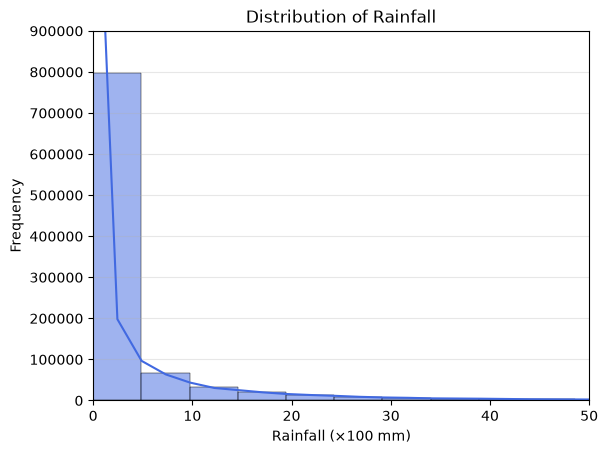

In [38]:
sns.histplot(df, x=df["rainfall"], bins=100, kde=True, color="royalblue")

plt.title("Distribution of Rainfall")
plt.xlabel("Rainfall (×100 mm)")
plt.ylabel("Frequency")
plt.xlim(0,50)
plt.ylim(0, 900000)


plt.grid(axis="y", alpha=0.3)
plt.show()

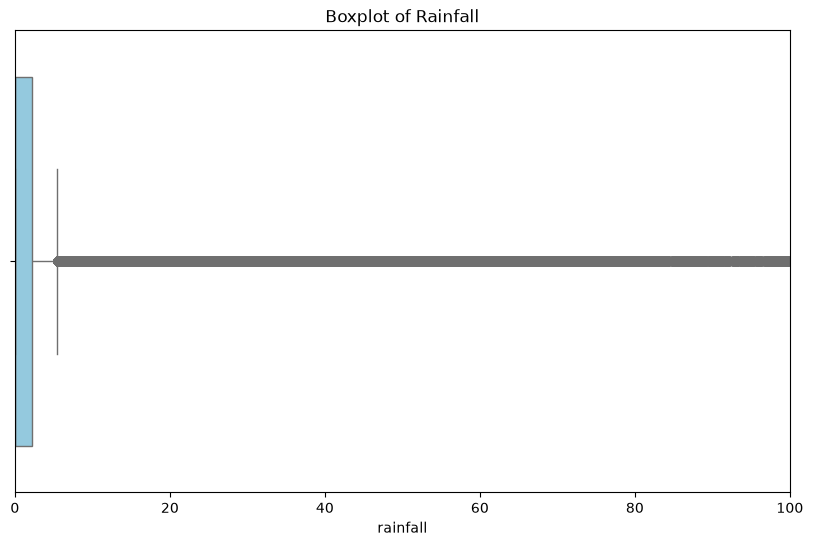

In [14]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x=df["rainfall"],
    color="skyblue"
)

plt.xlim(0,100)

plt.title("Boxplot of Rainfall")

plt.show()

### Observation

- Rainfall values are positively (right) skewed.
- Most observations record relatively low rainfall.
- A few observations have extremely high rainfall.
- The boxplot confirms the presence of several high-value outliers.
- These outliers correspond to heavy rainfall events and represent genuine weather conditions rather than data errors.

## Distribution of Average Temperature

This analysis explores how average temperature values are distributed across the dataset.

The histogram illustrates the frequency of temperatures, while the boxplot highlights variability and possible outliers.

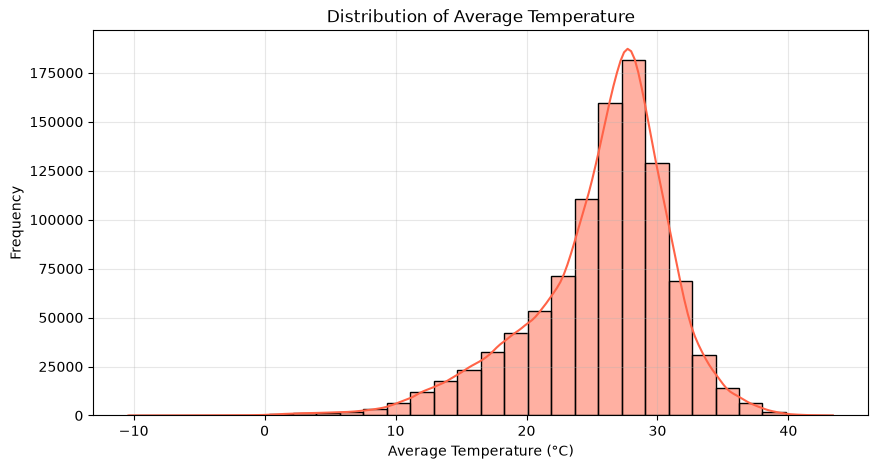

In [15]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x="avg_temp",
    bins=30,
    kde=True,
    color="tomato"
)

plt.title("Distribution of Average Temperature")

plt.xlabel("Average Temperature (°C)")
plt.ylabel("Frequency")

plt.grid(alpha=0.3)

plt.show()

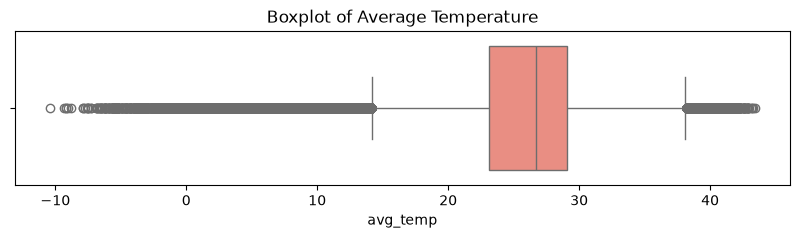

In [16]:
plt.figure(figsize=(10,2))

sns.boxplot(
    x=df["avg_temp"],
    color="salmon"
)

plt.title("Boxplot of Average Temperature")

plt.show()

### Observation

- Average temperature is approximately normally distributed.
- Most observations lie between 20°C and 32°C.
- Very few observations fall below 10°C or above 38°C.
- The boxplot indicates only a small number of outliers.
- Overall, temperature values are well distributed compared to rainfall.

## Distribution of Wind Speed

This section analyzes the distribution of wind speed across different weather observations.

The histogram shows how frequently different wind speed values occur, while the boxplot highlights the spread of the data and any outliers.

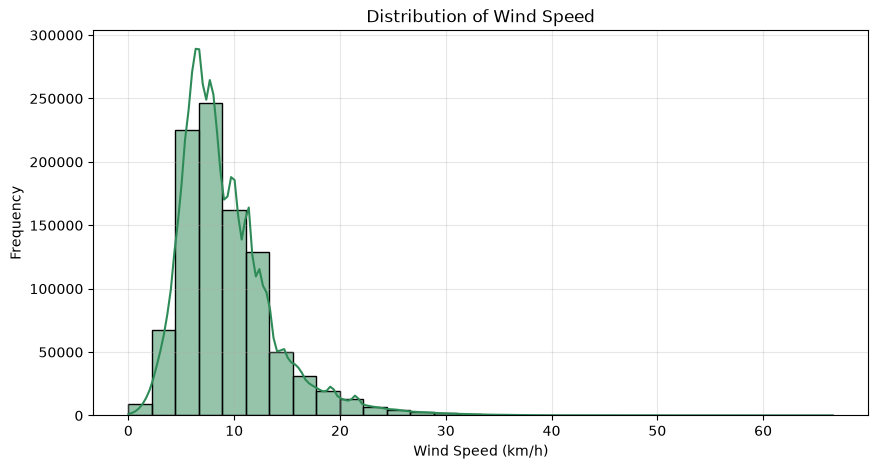

In [17]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x="wind_speed",
    bins=30,
    kde=True,
    color="seagreen"
)

plt.title("Distribution of Wind Speed")
plt.xlabel("Wind Speed (km/h)")
plt.ylabel("Frequency")

plt.grid(alpha=0.3)

plt.show()

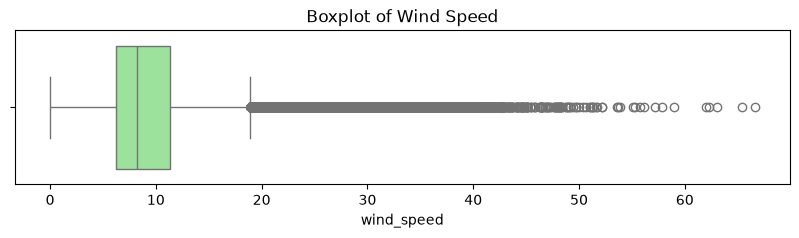

In [18]:
plt.figure(figsize=(10,2))

sns.boxplot(
    x=df["wind_speed"],
    color="lightgreen"
)

plt.title("Boxplot of Wind Speed")

plt.show()

### Observation

- Wind speed values are concentrated within a moderate range.
- The distribution is slightly right-skewed.
- A few observations have unusually high wind speeds.
- The boxplot confirms the presence of some outliers.

## Distribution of Air Pressure

Air pressure is an important atmospheric variable that influences weather conditions.

The following plots illustrate its frequency distribution and identify potential outliers.

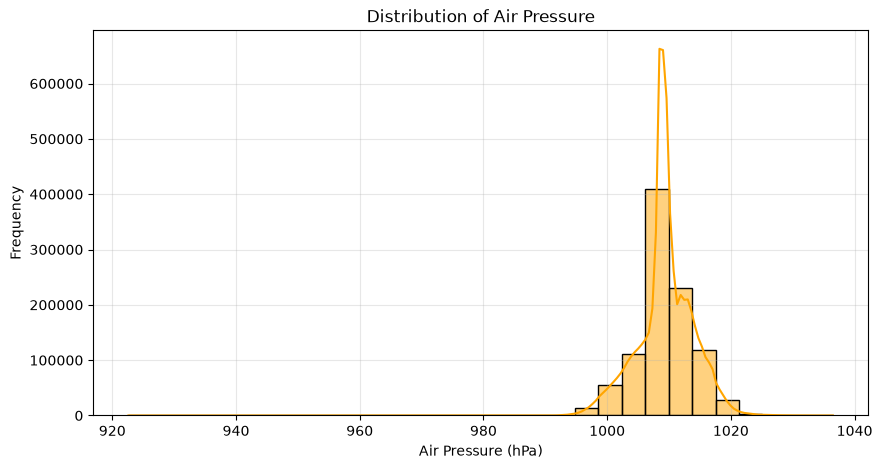

In [19]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x="air_pressure",
    bins=30,
    kde=True,
    color="orange"
)

plt.title("Distribution of Air Pressure")

plt.xlabel("Air Pressure (hPa)")
plt.ylabel("Frequency")

plt.grid(alpha=0.3)

plt.show()

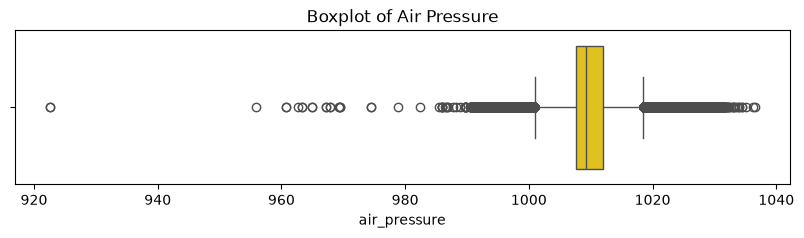

In [20]:
plt.figure(figsize=(10,2))

sns.boxplot(
    x=df["air_pressure"],
    color="gold"
)

plt.title("Boxplot of Air Pressure")

plt.show()

### Observation

- Air pressure values are approximately normally distributed.
- Most observations lie within a narrow pressure range.
- Only a few extreme observations appear as outliers.
- Overall, air pressure remains relatively stable across the dataset.

# Summary of Univariate Analysis

The univariate analysis reveals the following insights:

- Rainfall is highly right-skewed with several extreme rainfall events.
- Average temperature follows an approximately normal distribution.
- Wind speed exhibits moderate variability with a few high-value outliers.
- Air pressure remains relatively stable and shows only minor variation.

These observations provide a better understanding of the individual characteristics of each weather variable before exploring relationships between variables.

# Bivariate Analysis

Bivariate analysis examines the relationship between two variables. It helps identify trends, correlations and seasonal patterns in the weather dataset.

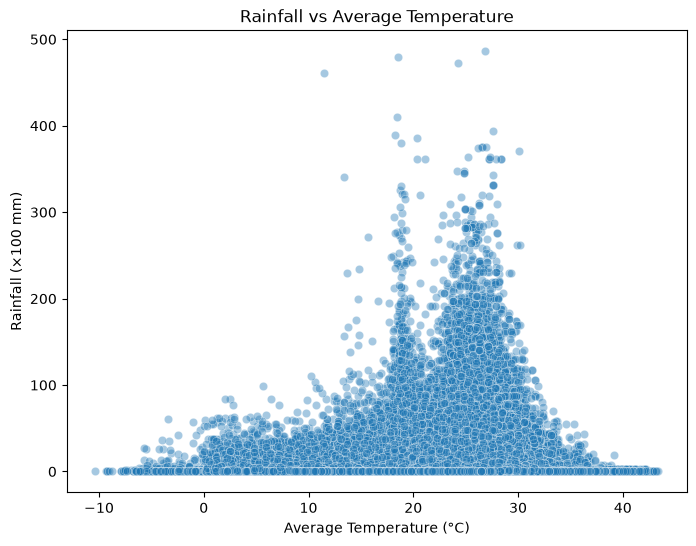

In [21]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="avg_temp",
    y="rainfall",
    alpha=0.4
)

plt.title("Rainfall vs Average Temperature")
plt.xlabel("Average Temperature (°C)")
plt.ylabel("Rainfall (×100 mm)")

plt.show()

### Observation

- Moderate rainfall occurs over a wide temperature range.
- Extremely high rainfall occurs around moderate temperatures.
- Temperature alone does not determine rainfall.

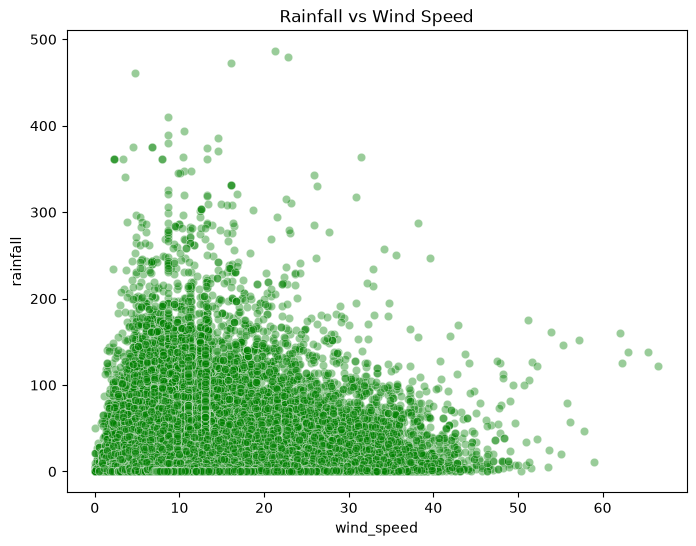

In [22]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="wind_speed",
    y="rainfall",
    alpha=0.4,
    color="green"
)

plt.title("Rainfall vs Wind Speed")

plt.show()

### Observation
- Higher rainfall generally occurs with higher wind speeds.

- Heavy rainfall events are associated with stronger winds.

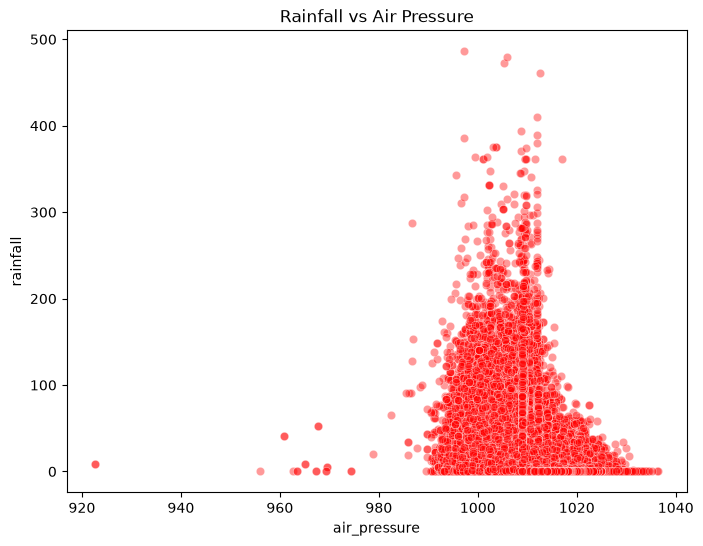

In [23]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="air_pressure",
    y="rainfall",
    alpha=0.4,
    color="red"
)

plt.title("Rainfall vs Air Pressure")

plt.show()

### Observation
- Heavy rainfall mostly occurs during lower air pressure conditions.

- High-pressure conditions generally correspond to lower rainfall.

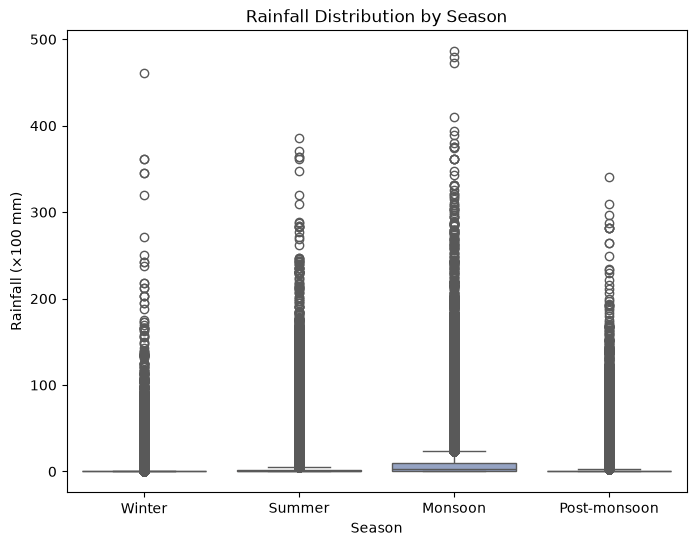

In [24]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x="season",
    y="rainfall",
    hue="season",
    palette="Set2",
    legend=False
)

plt.title("Rainfall Distribution by Season")
plt.xlabel("Season")
plt.ylabel("Rainfall (×100 mm)")

plt.show()

### Observation
- Monsoon season records the highest rainfall.

- Winter experiences the lowest rainfall.

- Rainfall variability is greatest during the monsoon.

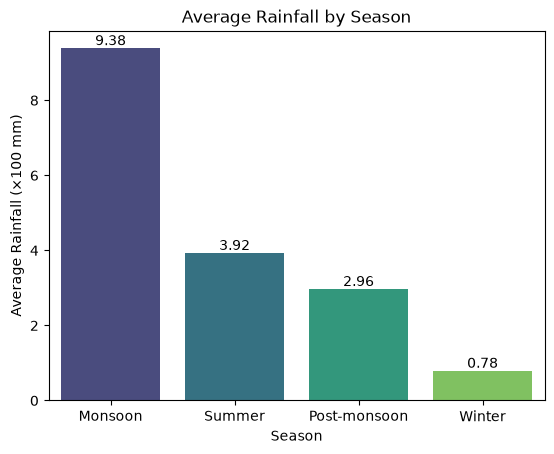

In [25]:
season_df = (
    df.groupby("season")["rainfall"]
      .mean()
      .sort_values(ascending=False)
      .reset_index()
)

season_df

ax = sns.barplot(
    data=season_df,
    x="season",
    y="rainfall",
    hue="season",
    palette="viridis",
    legend=False
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")

plt.title("Average Rainfall by Season")
plt.xlabel("Season")
plt.ylabel("Average Rainfall (×100 mm)")

plt.show()

### Observation
- Monsoon contributes the highest average rainfall.

- Summer acts as a transition before peak rainfall.

- Winter and post-monsoon receive comparatively less rainfall.

# Time Series Analysis

Time series analysis helps understand how weather variables change over time. This section explores monthly and yearly trends in rainfall and temperature to identify seasonal patterns and long-term variations.

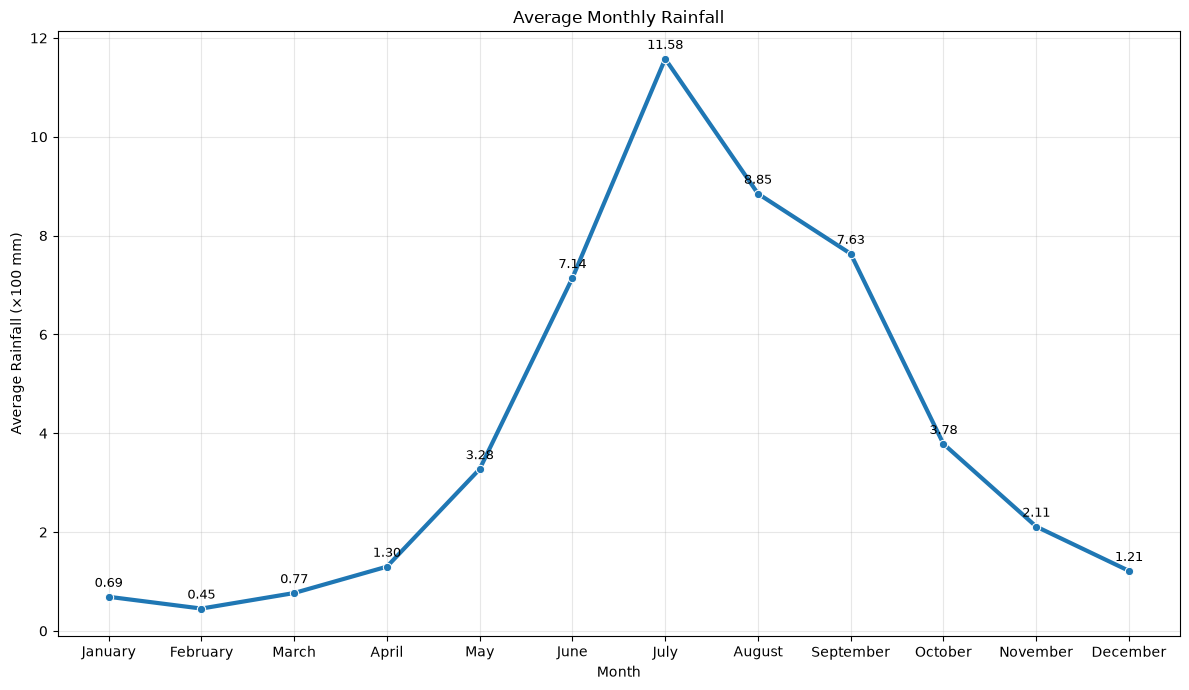

In [26]:
month_order = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

monthly_rain=(
    df.groupby('month')['rainfall']
    .mean()
    .reindex(month_order)
    .reset_index()
)


plt.figure(figsize=(12,7))

sns.lineplot(
    data=monthly_rain,
    x="month",
    y="rainfall",
    marker="o",
    linewidth=3
)

for x, y in zip(monthly_rain["month"], monthly_rain["rainfall"]):
    plt.text(x, y + 0.2, f"{y:.2f}", ha="center", fontsize=9)

plt.title("Average Monthly Rainfall")
plt.xlabel("Month")
plt.ylabel("Average Rainfall (×100 mm)")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Observation

- Rainfall remains low from January to April.
- Rainfall increases rapidly from May onward.
- July records the highest average rainfall.
- Rainfall gradually decreases after September.

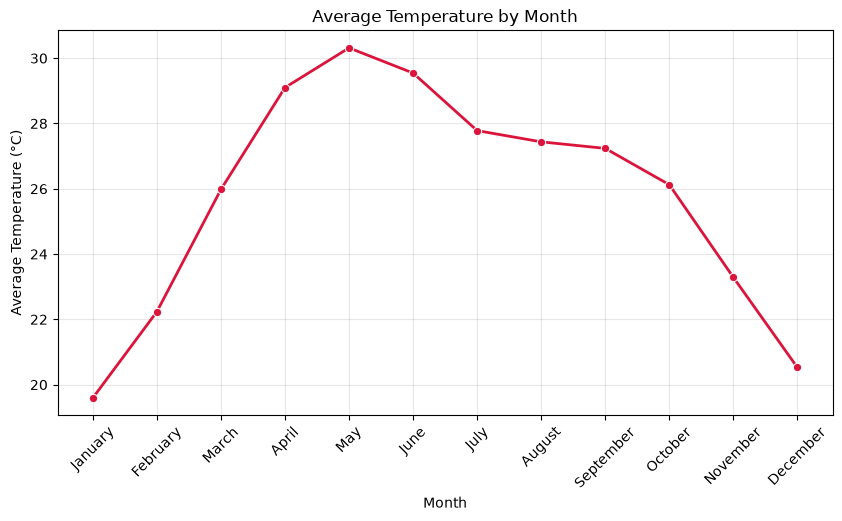

In [27]:
monthly_temp = (
    df.groupby("month")["avg_temp"]
      .mean()
      .reindex(month_order)
      .reset_index()
)

plt.figure(figsize=(10,5))

sns.lineplot(
    data=monthly_temp,
    x="month",
    y="avg_temp",
    marker="o",
    linewidth=2,
    color="crimson"
)

plt.title("Average Temperature by Month")
plt.xlabel("Month")
plt.ylabel("Average Temperature (°C)")
plt.xticks(rotation=45)

plt.grid(alpha=0.3)

plt.show()

### Observation

- Temperature gradually rises from January.
- Peak temperatures occur during May and June.
- Temperature decreases after the onset of the monsoon.
- Winter months record the lowest average temperatures.

### Note

Data for **2025** has been excluded from the yearly trend analysis because it contains significantly fewer observations (**16,773 records**) compared to previous years (approximately **148,000 records** per year). Including this incomplete year could produce misleading yearly averages and distort the trend.

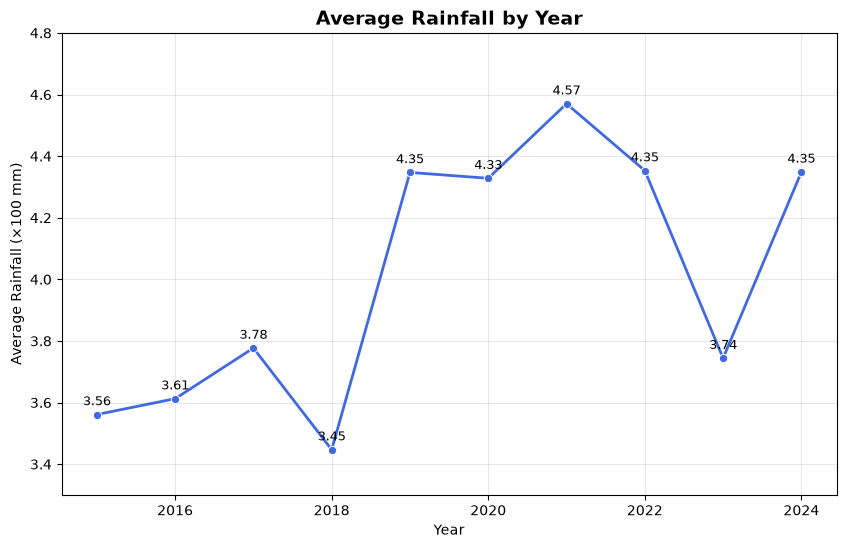

In [28]:
# Exclude incomplete year (2025)
df_year = df[df["year"] != 2025]

# Calculate average rainfall by year
year_rainfall = (
    df_year.groupby("year")["rainfall"]
           .mean()
           .reset_index()
)

# Plot
plt.figure(figsize=(10,6))

ax = sns.lineplot(
    data=year_rainfall,
    x="year",
    y="rainfall",
    marker="o",
    linewidth=2,
    color="royalblue"
)

# Add value labels
for x, y in zip(year_rainfall["year"], year_rainfall["rainfall"]):
    plt.text(
        x,
        y + 0.03,
        f"{y:.2f}",
        ha="center",
        fontsize=9
    )

plt.title("Average Rainfall by Year", fontsize=14, weight="bold")
plt.xlabel("Year")
plt.ylabel("Average Rainfall (×100 mm)")
plt.grid(alpha=0.3)
plt.ylim(3.3, 4.8)

plt.show()

### Observation

- Average rainfall varied moderately between 2015 and 2024.
- The highest average rainfall was recorded in 2021 (≈ 4.57 ×100 mm).
- The lowest average rainfall was observed in 2018 (≈ 3.45 ×100 mm).
- Average rainfall declined in 2023 and increased again in 2024.
- Data for 2025 was excluded because it contains significantly fewer observations than previous years, which could lead to misleading yearly averages.

### Note

Data for **2025** has been excluded from the yearly temperature trend analysis because it contains significantly fewer observations (**16,773 records**) compared to previous years (approximately **148,000 records** per year). Including this incomplete year could produce misleading yearly averages and distort the trend.

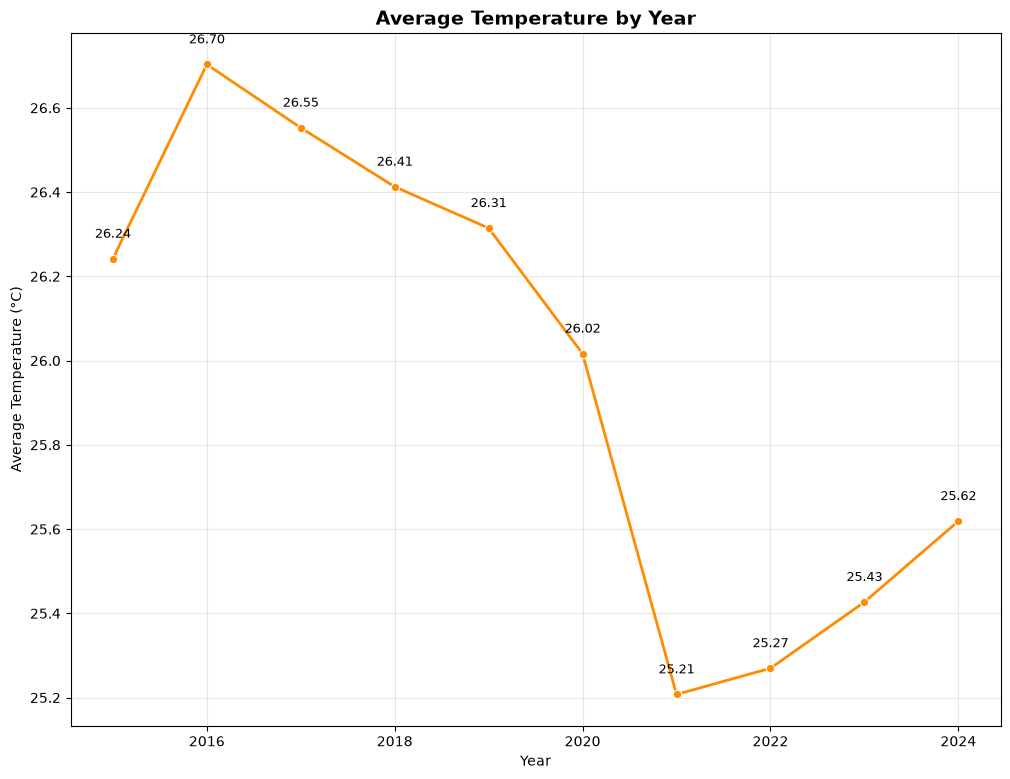

In [29]:
year_temp = (
    df_year.groupby("year")["avg_temp"]
           .mean()
           .reset_index()
)

plt.figure(figsize=(12,9))

sns.lineplot(
    data=year_temp,
    x="year",
    y="avg_temp",
    marker="o",
    linewidth=2,
    color="darkorange"
)

# Value labels
for x, y in zip(year_temp["year"], year_temp["avg_temp"]):
    plt.text(
        x,
        y + 0.05,
        f"{y:.2f}",
        ha="center",
        fontsize=9
    )

plt.title("Average Temperature by Year", fontsize=14, weight="bold")
plt.xlabel("Year")
plt.ylabel("Average Temperature (°C)")
plt.grid(alpha=0.3)

plt.show()

### Observation

- Average temperature remained relatively stable between 2015 and 2024.
- The highest average temperature was recorded in 2016 (≈26.7°C).
- Average temperature showed a gradual decline from 2017 to 2021.
- A slight recovery in average temperature was observed during 2022–2024.
- Data for 2025 was excluded because it contains significantly fewer observations than previous years, which could lead to misleading yearly averages. 

# State-wise Analysis

In [30]:
state_map = {
    "AP": "Andhra Pradesh",
    "AR": "Arunachal Pradesh",
    "AS": "Assam",
    "BR": "Bihar",
    "CH": "Chandigarh",
    "CT": "Chhattisgarh",
    "DD": "Daman and Diu",
    "DL": "Delhi",
    "DN": "Dadra and Nagar Haveli",
    "GA": "Goa",
    "GJ": "Gujarat",
    "HP": "Himachal Pradesh",
    "HR": "Haryana",
    "JK": "Jammu and Kashmir",
    "JH": "Jharkhand",
    "KA": "Karnataka",
    "KL": "Kerala",
    "LA": "Ladakh",
    "LD": "Lakshadweep",
    "MH": "Maharashtra",
    "ML": "Meghalaya",
    "MN": "Manipur",
    "MP": "Madhya Pradesh",
    "MZ": "Mizoram",
    "NL": "Nagaland",
    "OR": "Odisha",
    "PB": "Punjab",
    "PY": "Puducherry",
    "RJ": "Rajasthan",
    "SK": "Sikkim",
    "TG": "Telangana",
    "TN": "Tamil Nadu",
    "TR": "Tripura",
    "UP": "Uttar Pradesh",
    "UT": "Uttarakhand",
    "WB": "West Bengal",
    "AN": "Andaman and Nicobar Islands"
}
df["state_name"] = df["state"].map(state_map)

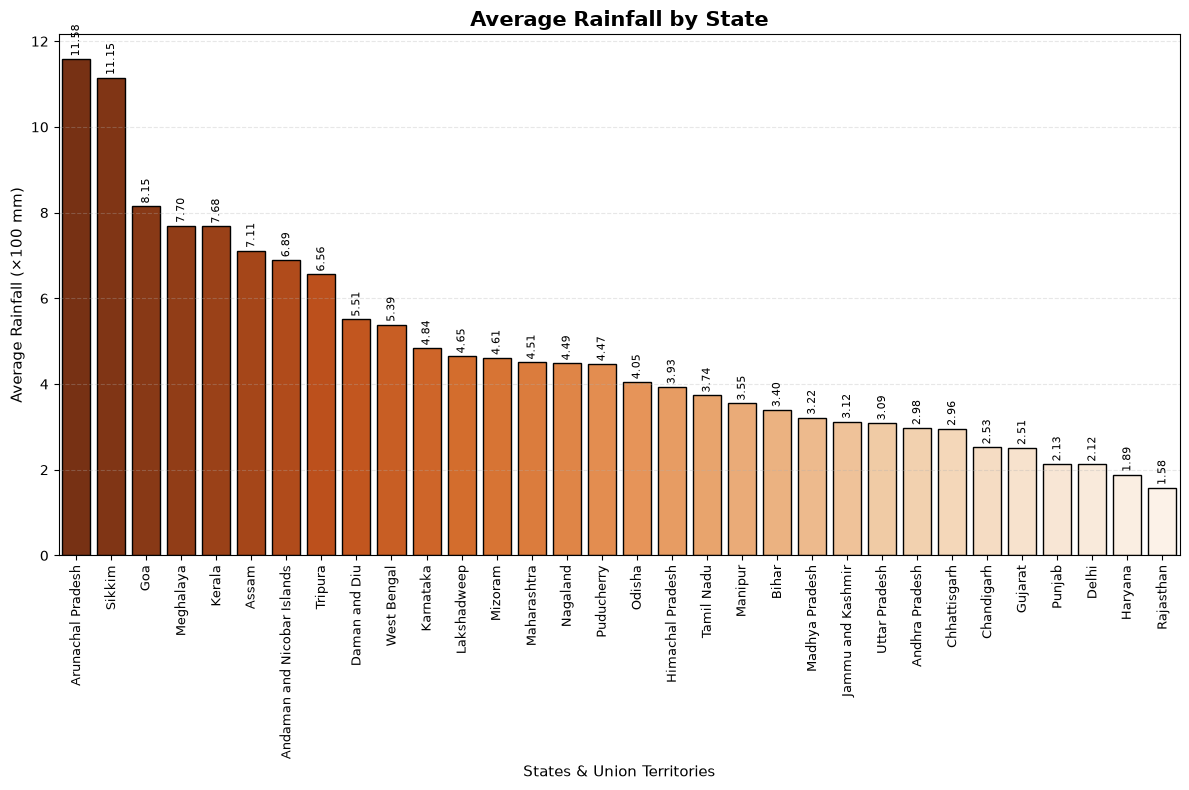

In [31]:
state_rainfall = (
    df.groupby("state_name", as_index=False)["rainfall"]
      .mean()
      .sort_values("rainfall", ascending=False)
)

plt.figure(figsize=(12,8))

ax = sns.barplot(
    data=state_rainfall,
    x="state_name",
    y="rainfall",
    hue="state_name",          
    palette='Oranges_r',
    edgecolor='black',
    legend=False
)


for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", fontsize=8, padding=2, rotation=90)

plt.title("Average Rainfall by State", fontsize=15, fontweight="bold")
plt.xlabel("States & Union Territories", fontsize=11)
plt.ylabel("Average Rainfall (×100 mm)", fontsize=11)

plt.xticks(rotation=90, fontsize=9)
plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

### Observation

- Arunachal Pradesh receives the highest average rainfall.
- Rajasthan records the lowest average rainfall.
- Northeastern states generally experience heavier rainfall than western states.

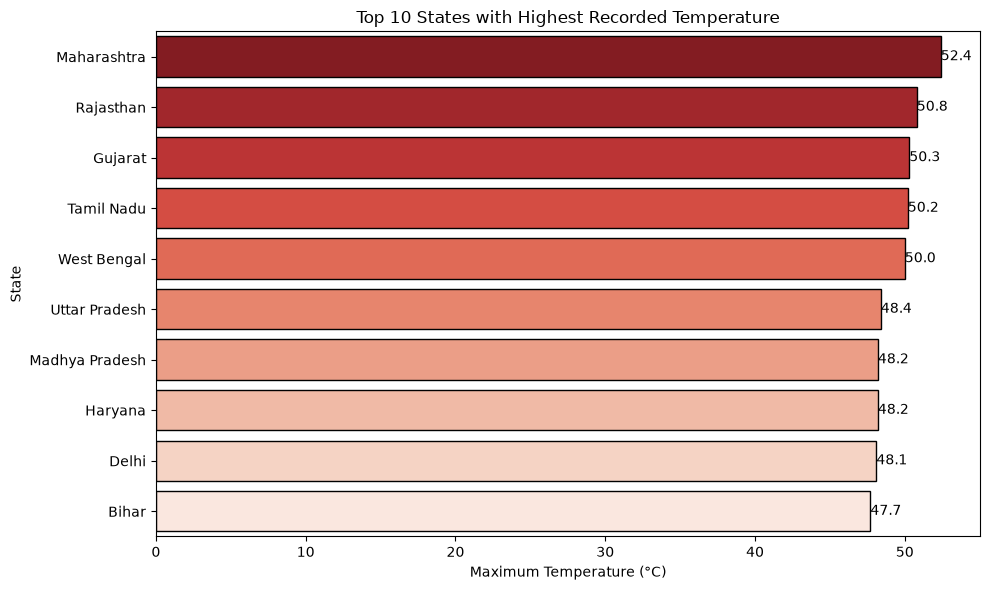

In [37]:
top_hot = (
    df.groupby("state_name")["max_temp"]
      .max()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)

plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=top_hot,
    y="state_name",
    x="max_temp",
    hue="state_name",
    palette="Reds_r",
    edgecolor='Black',
    legend=False
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f")

plt.title("Top 10 States with Highest Recorded Temperature")
plt.xlabel("Maximum Temperature (°C)")
plt.ylabel("State")

plt.tight_layout()
plt.show()

### Observation

- Western and central Indian states record the highest temperatures.
- Rajasthan and neighboring regions dominate the list.

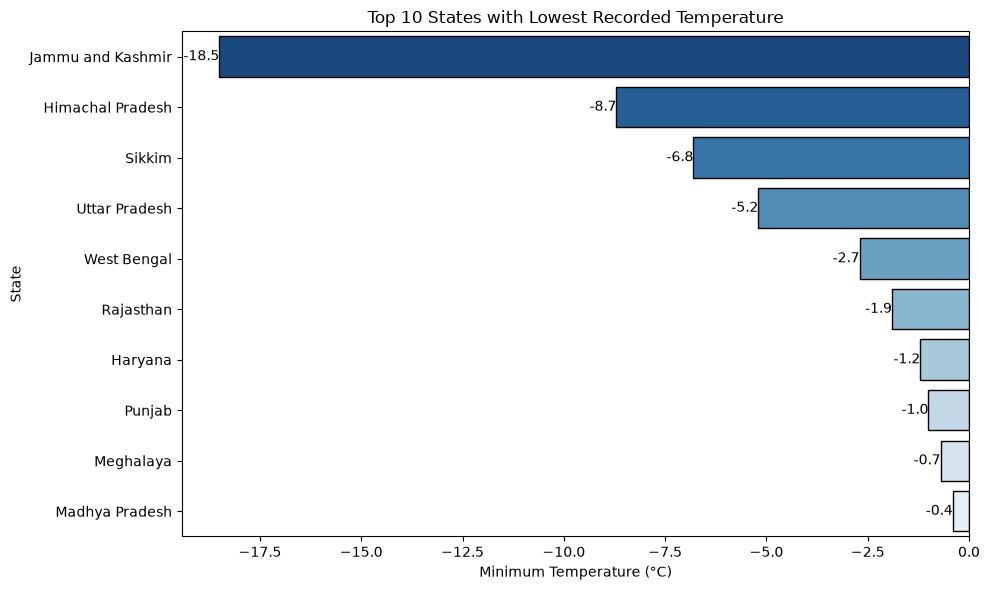

In [33]:
cold = (
    df.groupby("state_name")["min_temp"]
      .min()
      .sort_values()
      .head(10)
      .reset_index()
)

plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=cold,
    y="state_name",
    x="min_temp",
    hue="state_name",
    palette="Blues_r",
    edgecolor="black",
    legend=False
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f")

plt.title("Top 10 States with Lowest Recorded Temperature")
plt.xlabel("Minimum Temperature (°C)")
plt.ylabel("State")

plt.tight_layout()
plt.show()

### Observation

- Himalayan states record the lowest temperatures.
- Jammu & Kashmir and neighboring mountainous regions dominate the coldest temperatures.

## Correlation Analysis

In [34]:
df_corr = df[
    [
        "avg_temp",
        "min_temp",
        "max_temp",
        "wind_speed",
        "air_pressure",
        "elevation",
        "latitude",
        "longitude",
        "rainfall",
    ]
].corr()
df_corr

,avg_temp,min_temp,max_temp,wind_speed,air_pressure,elevation,latitude,longitude,rainfall
avg_temp,1.000000,0.916090,0.913189,0.261708,-0.603595,-0.439128,-0.296834,-0.054894,0.006829
min_temp,0.916090,1.000000,0.753938,0.345896,-0.635141,-0.428519,-0.383497,-0.020615,0.118151
max_temp,0.913189,0.753938,1.000000,0.162818,-0.505950,-0.403809,-0.203176,-0.100496,-0.098176
wind_speed,0.261708,0.345896,0.162818,1.000000,-0.246099,-0.179130,-0.347881,-0.232713,0.081460
air_pressure,-0.603595,-0.635141,-0.505950,-0.246099,1.000000,0.234684,-0.001579,-0.049422,-0.180831
elevation,-0.439128,-0.428519,-0.403809,-0.179130,0.234684,1.000000,0.209737,-0.102063,-0.013434
latitude,-0.296834,-0.383497,-0.203176,-0.347881,-0.001579,0.209737,1.000000,0.127987,-0.048308
longitude,-0.054894,-0.020615,-0.100496,-0.232713,-0.049422,-0.102063,0.127987,1.000000,0.050088
rainfall,0.006829,0.118151,-0.098176,0.081460,-0.180831,-0.013434,-0.048308,0.050088,1.000000


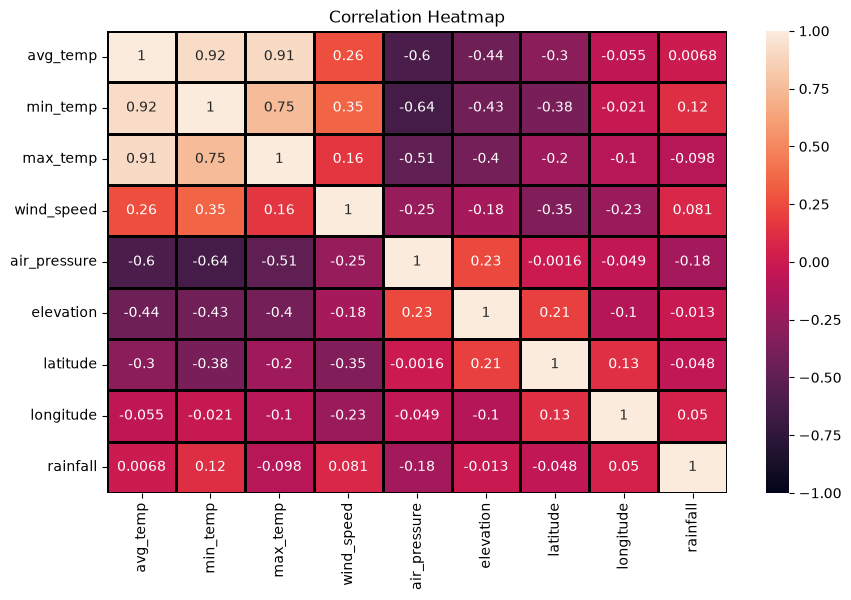

In [35]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df_corr,
    annot=True,
    linewidth=1,
    linecolor="black",
    cmap="rocket",
    vmin=-1,
    vmax=1,
)

plt.title("Correlation Heatmap")
plt.show()

### Observation

- Average, minimum, and maximum temperatures are strongly positively correlated.
- Air pressure has a moderate negative correlation with temperature.
- Rainfall has a weak relationship with temperature variables.
- Wind speed shows only a slight positive correlation with rainfall.
- Overall, temperature variables exhibit the strongest relationships in the dataset.